In [ ]:

pip install twilio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 37.9 MB/s eta 0:00:00


In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from twilio.rest import Client  # For sending SMS alerts
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
import requests

API_KEY = "fb6b8dd6ff7d9c1131bf85e96eeeae51"
BASE_URL = "http://api.openweathermap.org/data/2.5/weather"

# Step 1: Input states and cities
state_cities = {}
num_states = int(input("How many states do you want to enter? "))

for _ in range(num_states):
    state = input("Enter state name: ").strip()
    num_cities = int(input(f"  How many cities for {state}? "))

    cities = []
    for _ in range(num_cities):
        city = input("    Enter city name: ").strip()
        cities.append(city)

    state_cities[state] = cities

# Step 2: Fetch weather data
weather_data = {}

for state, cities in state_cities.items():
    print(f"\n🌍 State: {state}")
    state_weather = {}

    for city in cities:
        params = {
            "q": city,
            "appid": API_KEY,
            "units": "metric"
        }

        response = requests.get(BASE_URL, params=params)

        if response.status_code == 200:
            data = response.json()

            # Extract rain description (text like "light rain")
            weather_desc = data['weather'][0]['description'].title()

            # Extract rain volume (if present)
            rain_volume = "Not reported"
            if 'rain' in data:
                if '1h' in data['rain']:
                    rain_volume = f"{data['rain']['1h']} mm (last 1h)"
                elif '3h' in data['rain']:
                    rain_volume = f"{data['rain']['3h']} mm (last 3h)"

            city_weather = {
                "Temperature": f"{data['main']['temp']} °C",
                "Humidity": f"{data['main']['humidity']} %",
                "Weather": weather_desc,
                "Wind": f"{data['wind']['speed']} m/s",
                "Rain Description": weather_desc if "rain" in weather_desc.lower() else "No rain",
                "Rain Volume": rain_volume,
                "Clouds": f"{data['clouds']['all']} %"
            }

            state_weather[city] = city_weather
            print(f"\n✅ {city} Weather:")
            for key, value in city_weather.items():
                print(f"   {key}: {value}")
        else:
            print(f"\n⚠️ Failed to get data for {city} (Error: {response.status_code})")

    weather_data[state] = state_weather




How many states do you want to enter? 1
Enter state name: Telangana
  How many cities for Telangana? 1
    Enter city name: Hyderabad

🌍 State: Telangana

✅ Hyderabad Weather:
   Temperature: 25.16 °C
   Humidity: 45 %
   Weather: Scattered Clouds
   Wind: 0.88 m/s
   Rain Description: No rain
   Rain Volume: Not reported
   Clouds: 49 %


In [ ]:
for state,cities in state_cities.items():
    print(f"\n🌍 State: {state}")
    state_weather = {}

    for city in cities:
        params = {
            "q": city,
            "appid": API_KEY,
            "units": "metric"
        }

        response = requests.get(BASE_URL, params=params)

        if response.status_code == 200:
            data = response.json()

            temp = data['main']['temp']
            humidity = data['main']['humidity']
            weather_desc = data['weather'][0]['description'].title()
            wind = data['wind']['speed']
            rain = data['rain'].get('1h', 0) if 'rain' in data else 0
            clouds = data['clouds']['all']

            # 💡 Disconnection logic
            if rain >10:
                risk = "High Risk (Heavy Rain)"
            elif wind> 10:
                risk = "Medium Risk (Strong Wind)"
            elif clouds < 90 and humidity > 80:
                risk = "Possible Risk (Cloudy + High Humidity)"
            else:
                risk = "No Risk"

            city_weather = {
                "Temperature": f"{temp} °C",
                "Humidity": f"{humidity} %",
                "Weather": weather_desc,
                "Wind": f"{wind} m/s",
                "Rain": f"{rain} mm",
                "Clouds": f"{clouds} %",
                "Disconnection Risk": risk
            }

            state_weather[city] = city_weather
            print(f"  ✅ {city}: {city_weather}")



🌍 State: Telangana
  ✅ Hyderabad: {'Temperature': '25.16 °C', 'Humidity': '45 %', 'Weather': 'Scattered Clouds', 'Wind': '0.88 m/s', 'Rain': '0 mm', 'Clouds': '49 %', 'Disconnection Risk': 'No Risk'}


In [ ]:
predicted = []
actual = []

print("\n--- Weather Risk & Accuracy Evaluation ---\n")

for state, cities in state_cities.items():
    for city in cities:
        params = {
            "q": city,
            "appid": API_KEY,
            "units": "metric"
        }

        response = requests.get(BASE_URL, params=params)

        if response.status_code == 200:
            data = response.json()

            temp = data['main']['temp']
            humidity = data['main']['humidity']
            weather_desc = data['weather'][0]['description'].title()
            wind = data['wind']['speed']
            rain = data['rain'].get('1h', 0) if 'rain' in data else 0
            clouds = data['clouds']['all']

            # 4. Predicted Risk Logic
            if rain > 10:
                risk = "High Risk"
            elif wind > 10:
                risk = "Medium Risk"
            elif clouds > 80 and humidity > 80:
                risk = "Possible Risk"
            else:
                risk = "No Risk"

            predicted_val = 1 if risk != "No Risk" else 0
            predicted.append(predicted_val)

            # 5. Simulated Ground Truth (based on rain or wind)
            actual_val = 1 if (rain > 10 or wind > 10) else 0
            actual.append(actual_val)

            print(f"{city}, {state} -> Predicted: {risk} | Actual: {'Disconnection' if actual_val else 'No Disconnection'}")
        else:
            print(f"⚠️ Failed to fetch data for {city} (Error: {response.status_code})")

# 6. Accuracy Results
from sklearn.metrics import confusion_matrix, classification_report
accuracy = accuracy_score(actual, predicted)
print("\n✅ Accuracy:", round(accuracy * 100, 2), "%")
print("🔍 Confusion Matrix:\n", confusion_matrix(actual, predicted))
print("📊 Classification Report:\n", classification_report(actual, predicted))


--- Weather Risk & Accuracy Evaluation ---

Hyderabad, Telangana -> Predicted: No Risk | Actual: No Disconnection

✅ Accuracy: 100.0 %
🔍 Confusion Matrix:
 [[1]]
📊 Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [ ]:
account_sid = 'ACf47496ccd72cbe3658ccab354bab8125'
auth_token = '58a80fa1bfaf62f2749da29c041af482'

# Create a Twilio client (place inside the loop)
client = Client(account_sid, auth_token)

# Send SMS alert
if risk != "No Risk":
    message_body = (
        f"⚠️ Disconnection Alert for {city}, {state}: {risk}\n"
        f"🌡 Temperature: {city_weather['Temperature']}\n"
        f"💧 Humidity: {city_weather['Humidity']}\n"
        f"🌧 Rain: {city_weather['Rain']}\n"
        #f"🌬 Wind: {city_weather['Wind']}\n"
        f"☁️ Clouds: {city_weather['Clouds']}\n"
    )
    try:
        message = client.messages.create(
            to="+919398749642",       # Replace with your verified number
            from_="+18564859242",     # Your Twilio number
            body=message_body
        )
        print(f"  📞 SMS sent to {message.to}, SID: {message.sid}")
    except Exception as e:
        print(f"  ❌ Failed to send SMS: {e}")


else:
    print(f"  ⚠️ Failed to get data for {city} (Error: {response.status_code})")

    weather_data[state] = state_weather

  ⚠️ Failed to get data for Hyderabad (Error: 200)


Enter city name: hyderabad
Coordinates for hyderabad: 17.360589, 78.4740613


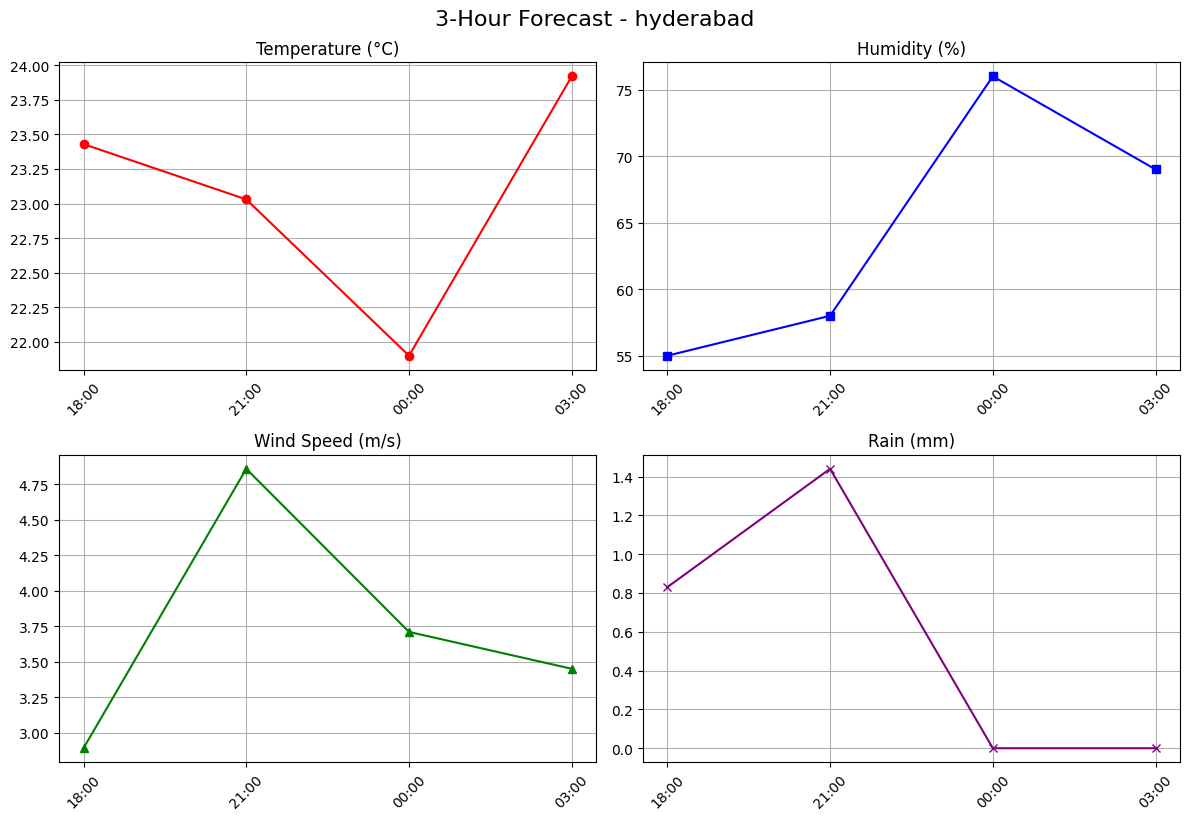

In [ ]:
from geopy.geocoders import Nominatim
from datetime import datetime
import requests
import matplotlib.pyplot as plt

# Get city input
city_name = input("Enter city name: ")

# Use geopy to get coordinates of the city
geolocator = Nominatim(user_agent="weather_app")
location = geolocator.geocode(city_name)

if not location:
    print("City not found.")
    exit()

lat = location.latitude
lon = location.longitude
print(f"Coordinates for {city_name}: {lat}, {lon}")

# Call OpenWeatherMap Forecast API
# The BASE_URL in the previous cells is for current weather, not forecast.
# Need to use the forecast API endpoint.
FORECAST_URL = "http://api.openweathermap.org/data/2.5/forecast"

params = {
    "lat": lat,
    "lon": lon,
    "appid": API_KEY, # Assuming API_KEY is defined in a previous cell
    "units": "metric"
}

response = requests.get(FORECAST_URL, params=params)
data = response.json()

# Check if the API call was successful
if response.status_code != 200:
    print(f"Error fetching weather data: {data.get('message', 'Unknown error')}")
else:
    # Take next 4 forecasts (next 12 hours) - Each forecast is for 3 hours, so 4 forecasts cover 12 hours.
    # The forecast data is in the 'list' key
    forecast_data = data["list"][:4]

    time_labels = [datetime.fromtimestamp(item["dt"]).strftime('%H:%M') for item in forecast_data]
    temps = [item["main"]["temp"] for item in forecast_data]
    humidity = [item["main"]["humidity"] for item in forecast_data]
    wind = [item["wind"]["speed"] for item in forecast_data]
    rain = [item.get("rain", {}).get("3h", 0) for item in forecast_data] # Use '3h' for forecast data

    # Plot
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.plot(time_labels, temps, marker='o', color='red')
    plt.title("Temperature (°C)")
    plt.xticks(rotation=45)
    plt.grid()

    plt.subplot(2, 2, 2)
    plt.plot(time_labels, humidity, marker='s', color='blue')
    plt.title("Humidity (%)")
    plt.xticks(rotation=45)
    plt.grid()

    plt.subplot(2, 2, 3)
    plt.plot(time_labels, wind, marker='^', color='green')
    plt.title("Wind Speed (m/s)")
    plt.xticks(rotation=45)
    plt.grid()

    plt.subplot(2, 2, 4)
    plt.plot(time_labels, rain, marker='x', color='purple')
    plt.title("Rain (mm)")
    plt.xticks(rotation=45)
    plt.grid()

    plt.tight_layout()
    plt.suptitle(f"3-Hour Forecast - {city_name}", fontsize=16, y=1.02)
    plt.show()

In [ ]:
pip install gtts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 7.5 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.2.1
    Uninstalling click-8.2.1:
      Successfully uninstalled click-8.2.1


In [ ]:
# Determine risk based on conditions
# Check for rain using the 'Weather' key and the 'Rain' key if it exists
if 'Weather' in city_weather and city_weather['Weather'].lower().startswith('heavy rain') or ('Rain' in city_weather and city_weather['Rain'] != "Not reported" and float(city_weather['Rain'].split()[0]) > 10):
    risk = "High Risk (Heavy Rain)"
elif float(city_weather['Wind'].split()[0]) > 7:
    risk = "Medium Risk (Strong Wind)"
elif float(city_weather['Clouds'].split()[0]) > 80 and float(city_weather['Humidity'].split()[0]) > 80:
    risk = "Possible Risk (Cloudy + High Humidity)"
else:
    risk = "No Risk"

# Send alert if risk is not 'No Risk'
if risk != "No Risk":
    messages = {
        "High Risk (Heavy Rain)": {
            "text": "Alert! High risk due to severe weather. Please prepare for a possible electricity disconnection.",
            "mp3_link": "https://drive.google.com/uc?id=1cQ17K1rDpj2yXfTWF7cDcurvf1EJICua&export=download"
        },
        "Medium Risk (Strong Wind)": {
            "text": "Alert! Medium Risk (Strong Wind). Please prepare for a possible electricity disconnection.",
            "mp3_link": "https://drive.google.com/uc?id=1H0wrCzeIKUMatYgJc8JcZx_Ltp9du3Zd&export=download"
        },
        "Possible Risk (Cloudy + High Humidity)": {
            "text": "Alert! Possible Risk due to cloudy weather and high humidity.",
            "mp3_link": "https://drive.google.com/uc?id=1QHVjP91zougUr3GoGs2vE20yD50P1QeO&export=download"
        }
    }

    msg = messages.get(risk)

    # Send SMS
    sms = client.messages.create(
        to=receiver_number,
        from_=twilio_number,
        body=(
            f"⚠️ Electricity Disconnection Alert: {risk}\n"
            f"🌡 Temp: {city_weather['Temperature']}\n"
            f"💧 Humidity: {city_weather['Humidity']}\n"
            f"🌧 Rain: {city_weather.get('Rain', 'N/A')}\n" # Use .get for safety
            f"🌬 Wind & ☁️ Clouds: {city_weather['Wind']}, {city_weather['Clouds']}\n"
            f"🔊 Listen to alert: {msg['mp3_link']}"
        )
    )
    print("✅ SMS sent:", sms.sid)

    # Voice call
    voice_response = VoiceResponse()
    voice_response.say(msg["text"], voice='alice', language='en-US')

    call = client.calls.create(
        twiml=str(voice_response),
        to=receiver_number,
        from_=twilio_number
    )
    print("📞 Voice call placed:", call.sid)
else:
    risk = "No Risk" # Ensure risk is set to "No Risk" when no alert is sent
    print(f"✅ {city} - No risk detected. No alerts sent.\n")

✅ Hyderabad - No risk detected. No alerts sent.



In [ ]:
pip install gradio requests matplotlib


In [ ]:
import requests
import gradio as gr

API_KEY = "fb6b8dd6ff7d9c1131bf85e96eeeae51"

def get_weather(city):
    url = f"http://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}&units=metric"
    res = requests.get(url)

    if res.status_code != 200:
        return f"<h3 style='color:red;'>❌ Error: City not found or invalid API key.</h3>"

    data = res.json()
    weather = data["weather"][0]["description"].title()
    temp = data["main"]["temp"]
    feels_like = data["main"]["feels_like"]
    humidity = data["main"]["humidity"]
    wind = data["wind"]["speed"]
    clouds = data["clouds"]["all"]
    icon_code = data["weather"][0]["icon"]
    icon_url = f"http://openweathermap.org/img/wn/{icon_code}@2x.png"

    # HTML UI
    html_output = f"""
    <div style="
        font-family: 'Segoe UI', sans-serif;
        background: linear-gradient(135deg, #fdfbfb 0%, #ebedee 100%);
        max-width: 400px;
        margin: auto;
        padding: 25px 30px;
        border-radius: 20px;
        box-shadow: 0 4px 20px rgba(0, 0, 0, 0.1);
        text-align: center;
    ">
        <h2 style="margin-bottom: 10px; color: #333;">🌍 {city.title()}</h2>
        <img src="{icon_url}" width="100" style="margin-top:-10px;" />
        <h1 style="font-size: 42px; color: #222;">{temp}°C</h1>
        <p style="font-size: 18px; color: #666;">{weather}</p>
        <hr style="margin: 15px 0; border: 0; height: 1px; background: #ccc;">
        <div style="display: flex; justify-content: space-between; font-size: 16px; color: #444;">
            <div>💧 Humidity:<br><strong>{humidity}%</strong></div>
            <div>🌬 Wind:<br><strong>{wind} m/s</strong></div>
            <div>☁️ Clouds:<br><strong>{clouds}%</strong></div>
        </div>
        <p style="margin-top: 15px; font-size: 14px; color: #888;">Feels like: {feels_like}°C</p>
    </div>
    """
    return html_output

gr.Interface(
    fn=get_weather,
    inputs=gr.Textbox(label="Enter City", placeholder="e.g. Hyderabad"),
    outputs=gr.HTML(),
    title="🌤 Weather Now",
    description="Get real-time weather data by city name.",
    theme="default"
).launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://af044e493af1e2f27b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
